In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
df = pd.read_csv('../data/processed/Austin_Animal_processed.csv')
df.head()

,Animal ID,Name,DateTime,MonthYear,Date of Birth,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color,Age in Days
0,A814515,Quentin,05/06/2020 07:59:00 AM,May 2020,03/01/2018,Adoption,Foster,2,2,2 years,American Foxhound/Labrador Retriever,White/Brown,0.151515
1,A843327,*Mary,10/08/2021 01:25:00 PM,Oct 2021,09/29/2019,Transfer,Out State,2,0,2 years,Chihuahua Shorthair Mix,Black/White,0.151515
2,A803149,*Birch,08/31/2019 04:26:00 PM,Aug 2019,08/08/2019,Transfer,Partner,1,1,3 weeks,Domestic Shorthair,Brown Tabby,0.092653
3,A698049,Luigi,03/16/2015 02:50:00 PM,Mar 2015,06/05/2014,Transfer,Partner,1,3,9 months,Domestic Medium Hair Mix,Black/White,0.113325
4,A822928,*Primrose,01/24/2022 11:49:00 AM,Jan 2022,09/15/2010,Adoption,Foster,1,3,11 years,Domestic Shorthair,Torbie,0.424242


In [4]:
X = df[['Age in Days', 'Animal Type', 'Sex upon Outcome']]
y = df['Outcome Type']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [7]:
y_pred = clf.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7293250672593286

Classification Report:

                 precision    recall  f1-score   support

       Adoption       0.85      0.56      0.68      3166
           Died       0.00      0.00      0.00       109
       Disposal       0.00      0.00      0.00         2
     Euthanasia       0.56      0.05      0.10       460
        Missing       0.00      0.00      0.00        10
Return to Owner       0.00      0.00      0.00        53
       Transfer       0.69      0.93      0.79      4749

       accuracy                           0.73      8549
      macro avg       0.30      0.22      0.22      8549
   weighted avg       0.73      0.73      0.70      8549



c:\Users\nurha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\nurha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\nurha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


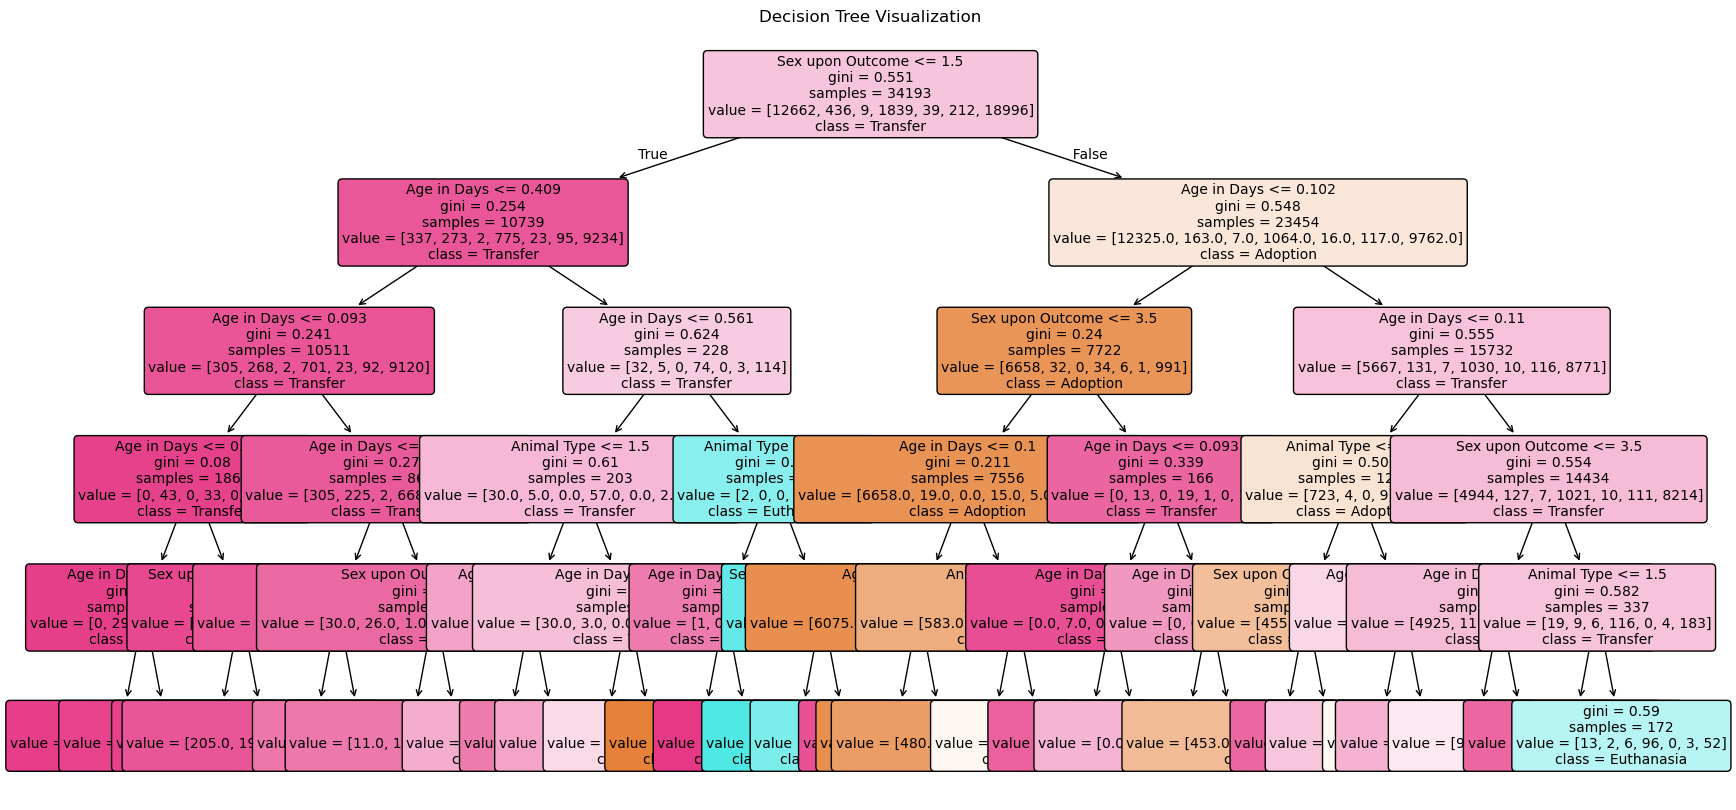

In [9]:
plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=X.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

In [10]:
# Train and Test Accuracy

train_accuracy = clf.score(X_train, y_train)

test_accuracy = clf.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Precision, Recall ve F1-Score 
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test), multi_class='ovr')
print(f"\nROC-AUC: {roc_auc:.4f}")

Train Accuracy: 0.7345
Test Accuracy: 0.7293

Precision: 0.7496
Recall: 0.7293
F1-Score: 0.6968

ROC-AUC: 0.7529


In [48]:
acc = accuracy_score(y_test, y_pred)

class_names = [
    "Adoption",
    "Died",
    "Disposal",
    "Euthanasia",
    "Missing",
    "Return to Owner",
    "Transfer"
]

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
)

with open("../outputs/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(f"Accuracy: {acc:.4f}\n\n")
    f.write(report)

with open("../outputs/model_accuracy.txt", "w", encoding="utf-8") as f:
    f.write(f"Decision Tree Accuracy: {acc:.4f}")

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png")
plt.close()

In [50]:
importances = clf.feature_importances_
features = X.columns

fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Decision Tree)")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../outputs/feature_importance.png")
plt.close()